In [12]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ['GROQ_API_KEY']:
    print("Groq API Key Set!")
else:
    raise ValueError("Groq API Key is not set!!")

Groq API Key Set!


In [13]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "llama-3.1-8b-instant")

llm.invoke("Hello!")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 37, 'total_tokens': 45, 'completion_time': 0.064236132, 'completion_tokens_details': None, 'prompt_time': 0.002898244, 'prompt_tokens_details': None, 'queue_time': 0.109705676, 'total_time': 0.067134376}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da163-9122-7d51-acf1-5a92d091f9d5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 8, 'total_tokens': 45})

## **FIRST GRAPH**

### Step 1: Define The Schema

In [14]:
from langgraph.graph import add_messages
from typing import TypedDict, List, Annotated

class graph_schema(TypedDict):

    messages : Annotated[List, add_messages] 

### Step 2: Create The Node Function

In [15]:
def welcome(state:graph_schema) -> graph_schema:

    curr_message = state['messages']

    response = llm.invoke(curr_message).content

    state['messages'] = f"Your message was {curr_message}. Here is my response: {response}"

    return state


### Step 3: Create The State Graph

In [16]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

#Adding Nodes
graph.add_node("Welcome", welcome)

#Adding Edges
graph.add_edge(START, "Welcome")
graph.add_edge("Welcome", END)


### Step 4: Compile The Graph

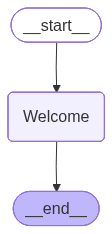

In [17]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

checkpoint = InMemorySaver()

memory_graph = graph.compile(checkpointer=checkpoint)

Image(memory_graph.get_graph().draw_mermaid_png())

### Step 5: Run The Graph With Config

In [23]:
response = memory_graph.invoke(
    {"messages" : "What is the meaning of my name?"},
    {'configurable' : {'thread_id':'Harsh Heralgi'}}
)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

My Name is Harsh
================================ Human Message =================================

Your message was [HumanMessage(content='My Name is Harsh', additional_kwargs={}, response_metadata={}, id='6a974134-e2f9-4cc4-b89b-0cb99d721784')]. Here is my response: Nice to meet you, Harsh. Is there something I can help you with or would you like to chat?
================================ Human Message =================================

What is my Name?
================================ Human Message =================================

Your message was [HumanMessage(content='My Name is Harsh', additional_kwargs={}, response_metadata={}, id='6a974134-e2f9-4cc4-b89b-0cb99d721784'), HumanMessage(content="Your message was [HumanMessage(content='My Name is Harsh', additional_kwargs={}, response_metadata={}, id='6a974134-e2f9-4cc4-b89b-0cb99d721784')]. Here is my response: Nice to meet you, Harsh. Is there someth